<a href="https://colab.research.google.com/github/yulia3006/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_4_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_K_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B8%D1%85_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Метод K-ближайших соседей**

Для всех классификаторов из Sklearn подбирайте лучшие гиперпараметры для модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

# **Базовый алгоритм KNN**

## **KNN для классификации**

### **Получение данных**

Будем работать с набором данным `iris` из `sklearn`.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (105, 4)
Размер тестовой выборки: (45, 4)


#### 1.2. Обучите модель KNN

In [6]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

#### 1.3. Проверьте качество работы модели

In [7]:
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9777777777777777


#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [9]:
k_range = range(1, 11)
scores = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred_k))

results = pd.DataFrame({'k': list(k_range), 'accuracy': scores})
print(results)



    k  accuracy
0   1  0.933333
1   2  0.911111
2   3  0.955556
3   4  0.955556
4   5  0.977778
5   6  0.933333
6   7  0.955556
7   8  0.933333
8   9  0.955556
9  10  0.955556


### **2. KNN рукописный**

#### 2.1. Возьмите два случайных тестовых объектов

In [13]:
test_indices = [5, 10]
test_samples = X_test.iloc[test_indices]
test_samples



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
140,6.7,3.1,5.6,2.4
14,5.8,4.0,1.2,0.2


#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [15]:
from sklearn.metrics.pairwise import euclidean_distances

# DataFrame в numpy массивы
X_train_array = X_train.values
test_samples_array = test_samples.values

# Рассчитываем расстояния (результат - матрица 2 x 140)
all_distances = euclidean_distances(test_samples_array, X_train_array)
print(all_distances)

[[3.37194306 1.75499288 4.92645917 0.34641016 2.1330729  0.42426407
  5.03388518 4.88773976 5.27351875 0.59160798 0.678233   5.07247474
  4.87237109 1.59687194 2.61916017 0.88317609 4.79374593 4.98497743
  0.24494897 1.28452326 4.75289386 1.08166538 1.3820275  1.56843871
  2.1        5.15266921 4.87134478 4.98196748 1.15758369 2.36008474
  4.84767986 4.97694686 2.27596134 2.54165301 5.15266921 5.06655702
  1.56204994 1.06301458 1.65227116 5.01996016 0.51961524 5.18652099
  1.57162336 4.99299509 0.60827625 2.41246762 4.71487009 1.12694277
  2.05426386 1.37113092 2.30217289 5.32728824 2.73861279 0.678233
  1.53948043 0.74833148 4.92950302 2.05182845 5.06162029 1.27279221
  1.3190906  2.50998008 0.87177979 1.24096736 1.74068952 0.5
  1.396424   4.98898787 0.26457513 1.39283883 2.16333077 1.7175564
  5.03487835 0.4472136  1.12249722 1.85741756 4.94469413 1.65529454
  0.34641016 4.55411901 5.59553393 1.15758369 0.96953597 1.07238053
  4.64112055 1.21243557 3.23573794 0.37416574 1.03923048 4

#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [21]:
k = 10
nearest_indices_1 = np.argsort(all_distances[0])[:k]
nearest_distances_1 = all_distances[0][nearest_indices_1]
print(nearest_indices_1)

nearest_indices_2 = np.argsort(all_distances[1])[:k]
nearest_distances_2 = all_distances[1][nearest_indices_2]
print(nearest_indices_2)

[18 68 78  3 87 96  5 73 65 40]
[102  27  30  43  89  84  72   2  20   7]


#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [22]:
classes_1 = y_train[nearest_indices_1]
classes_2 = y_train[nearest_indices_2]
print(classes_1)
print(classes_2)

pred_1 = np.bincount(classes_1).argmax()
pred_2 = np.bincount(classes_2).argmax()
print(f'Предсказание для первой точки: {pred_1}')
print(f'Предсказание для второй точки: {pred_2}')


[2 2 2 2 2 2 2 2 2 2]
[0 0 0 0 0 0 0 0 0 0]
Предсказание для первой точки: 2
Предсказание для второй точки: 0


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [23]:
print(f"Настоящее целевое значение для первого объекта: {y_test[test_indices[0]]}")
print(f"Настоящее целевое значение для второго объекта: {y_test[test_indices[1]]}")


Настоящее целевое значение для первого объекта: 2
Настоящее целевое значение для второго объекта: 0


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [24]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### **KNN из sklearn**

#### 3.1. Разбейте данные на обучение и тест

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=41, test_size=20)

Затем нормализуйте данные:

In [26]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

X_train = pd.DataFrame(mms.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(mms.transform(X_test[X_train.columns]), columns=X_train.columns)

#### 3.2. Обучите модель KNN


In [29]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=15)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


#### 3.3. Проверьте качество работы модели

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_test))
print(mean_absolute_error(y_test, y_pred))


1.0
0.3429735333333332


#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

,k,R2 score
0,1,0.837270
1,2,0.894826
2,3,0.848289
3,4,0.851396
4,5,0.851701
5,6,0.818075
6,7,0.816832
7,8,0.813795
8,9,0.831957
9,10,0.844133


<Axes: xlabel='k'>

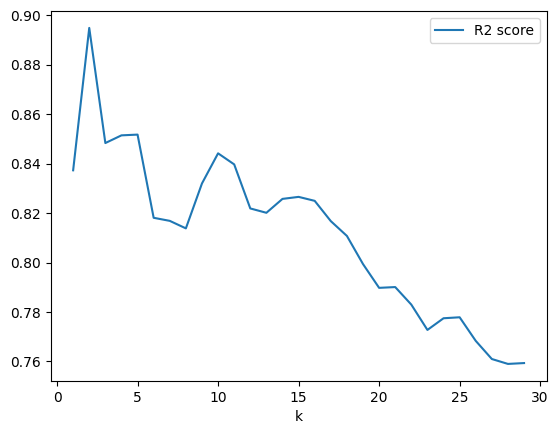

In [35]:
scores = []

for k in range(1, 30):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    score = r2_score(y_test, model.predict(X_test))
    scores.append(score)

results = pd.DataFrame({'k': [i for i in range(1, 30)], 'R2 score': scores})
display(results)
results.plot(x='k', y='R2 score')

### **4. KNN рукописный**

#### 4.1. Возьмите два случайных тестовых объектов

In [36]:
test_indices = [5, 10]
test_samples = X_test.iloc[test_indices]
test_samples

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
5,0.137177,0.980392,0.023530,0.025043,0.043163,0.002602,0.556854,0.212151
10,0.220618,0.235294,0.028175,0.019325,0.119062,0.001850,0.653560,0.297809


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [37]:
from sklearn.metrics.pairwise import euclidean_distances

# преобразуем DataFrame в numpy массивы
X_train_np = X_train.values
X_test_np = X_test.values

distances_matrix = euclidean_distances(X_test_np, X_train_np)
print(distances_matrix)

[[0.21810523 0.13630765 0.67242897 ... 0.6210845  0.64319716 0.69781815]
 [0.19805401 0.35938727 0.85823573 ... 0.90504099 0.85301822 0.96530451]
 [0.11330662 0.18879224 0.68813414 ... 0.75806724 0.65907596 0.75476519]
 ...
 [0.08326292 0.11408142 0.63555319 ... 0.68379561 0.62222217 0.72803343]
 [0.17007788 0.07778222 0.62479528 ... 0.61311873 0.60803332 0.6810462 ]
 [0.85555032 0.70316397 0.42855714 ... 0.58129353 0.34634464 0.14380048]]


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [38]:
import numpy as np

k = 10
nearest_indices_1 = np.argsort(all_distances[0])[:k]
nearest_distances_1 = all_distances[0][nearest_indices_1]
print(nearest_indices_1)

nearest_indices_2 = np.argsort(all_distances[1])[:k]
nearest_distances_2 = all_distances[1][nearest_indices_2]
print(nearest_indices_2)


[18 68 78  3 87 96  5 73 65 40]
[102  27  30  43  89  84  72   2  20   7]


#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [39]:
targets_1 = y_train[nearest_indices_1]
targets_2 = y_train[nearest_indices_2]
print(targets_1, targets_2)

pred_1 = np.mean(targets_1)
pred_2 = np.mean(targets_2)
print(pred_1, pred_2)


[1.865 2.325 0.712 2.933 1.503 2.781 2.3   1.382 2.707 1.943] [3.65  1.265 1.535 2.615 0.766 3.353 1.034 3.546 0.839 2.735]
2.0451 2.1338


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [40]:
print(f"Настоящее целевое значение для первого объекта: {y_test[test_indices[0]]}")
print(f"Настоящее целевое значение для второго объекта: {y_test[test_indices[1]]}")


Настоящее целевое значение для первого объекта: 1.191
Настоящее целевое значение для второго объекта: 0.933


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# **Weighted KNN**

## **KNN для классификации**

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [41]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [42]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [43]:
X_selected = X[['sepal length (cm)', 'petal width (cm)']]
X_selected

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2
...,...,...
145,6.7,2.3
146,6.3,1.9
147,6.5,2.0
148,6.2,2.3


### Визуализируйте ваши данные на графике

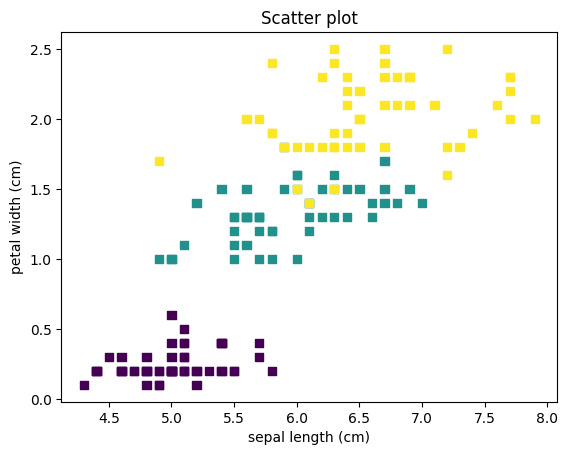

In [45]:
import matplotlib.pyplot as plt

plt.scatter(X_selected['sepal length (cm)'], X_selected['petal width (cm)'], c=y, cmap='viridis', marker='s')
plt.xlabel('sepal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Scatter plot')
plt.show()

### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, random_state=42, test_size=10)


#### 1.2. Обучите модель KNN на 50 соседях

In [49]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=30)
model.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=30)

#### 1.3. Проверьте качество работы модели

In [52]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('True:', y_test)
print('Pred:', y_pred)


Accuracy: 1.0
True: [1 0 2 1 1 0 1 2 1 1]
Pred: [1 0 2 1 1 0 1 2 1 1]


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [53]:
obj_idx = 5
x1 = X_test.iloc[obj_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df['Distance from obj'] = distance
distances_df


,Label,Distance from obj
0,2,1.941649
1,0,0.670820
2,0,0.223607
3,0,0.583095
4,0,0.316228
...,...,...
135,1,1.140175
136,2,1.392839
137,0,0.447214
138,1,0.894427


#### 1.5. Выберите топ  k  соседей


In [54]:
k=20
display(distances_df.sort_values('Distance from obj').head(k))


,Label,Distance from obj
33,0,0.000000
68,0,0.000000
34,0,0.200000
134,0,0.200000
61,0,0.223607
2,0,0.223607
114,0,0.223607
46,0,0.282843
27,0,0.282843
21,0,0.300000


#### 1.6. Выведите финальное предсказание для этого объекта

In [56]:
obj = distances_df.sort_values('Distance from obj').head(k)
display(obj['Label'].value_counts())
print(f"Предсказанный класс для объекта: {obj['Label'].value_counts().index[0]}")


,count
Label,
0,20


Предсказанный класс для объекта: 0


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [58]:
print(f"Настоящее целевое значение для объекта: {y_test[obj_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj_idx]}")


Настоящее целевое значение для объекта: 0
Предсказанное целевое значение для объекта: 0


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

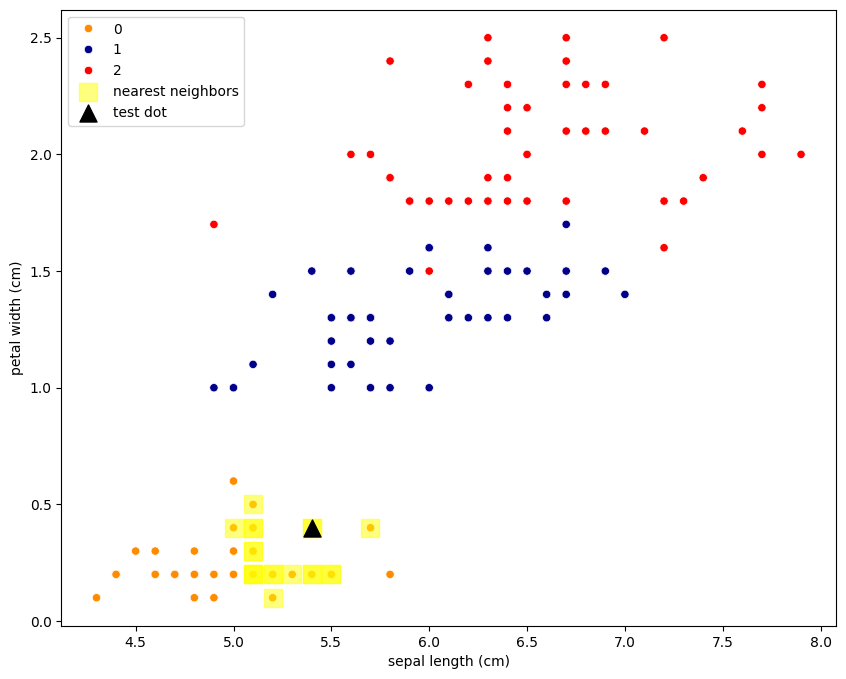

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_bold = ["darkorange", "darkblue", "red"]

nearest_neigbors_idxs = distances_df.sort_values('Distance from obj').head(k).index
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_train['sepal length (cm)'],
    y=X_train['petal width (cm)'],
    hue=y_train,
    palette=cmap_bold
)

# добавляем ближайших соседей на график
plt.scatter(
    X_train.iloc[nearest_neigbors_idxs]['sepal length (cm)'],
    X_train.iloc[nearest_neigbors_idxs]['petal width (cm)'],
    c='yellow',
    alpha=0.5,
    marker='s',
    s=150,
    label='nearest neighbors'
)

# добавляем тестовую точку на график
plt.scatter(
    X_test.iloc[obj_idx]['sepal length (cm)'],
    X_test.iloc[obj_idx]['petal width (cm)'],
    c='black',
    marker='^',
    s=150,
    label='test dot'
)

plt.legend()


### **2. Weighted KNN**

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [62]:
knn = KNeighborsClassifier(n_neighbors=30, weights='distance')
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=30, weights='distance')

#### 2.2. Проверьте качество работы модели


In [63]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
display(accuracy_score(y_test, y_pred))
display(y_test, y_pred)


0.9

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

array([1, 0, 2, 2, 1, 0, 1, 2, 1, 1])

#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [66]:
import numpy as np

obj_idx = 0
x1 = X_test.iloc[obj_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df['Distance from obj'] = distance
distances_df


,Label,Distance from obj
0,2,0.894427
1,0,1.702939
2,0,1.166190
3,0,1.627882
4,0,1.345362
...,...,...
135,1,0.100000
136,2,1.300000
137,0,1.044031
138,1,0.300000


#### 2.4. Выберите топ  k  соседей


In [69]:
k=10
display(distances_df.sort_values('Distance from obj').head(k))

,Label,Distance from obj
135,1,0.100000
59,1,0.141421
99,1,0.200000
110,1,0.200000
83,2,0.200000
64,1,0.223607
130,1,0.223607
138,1,0.300000
88,2,0.316228
131,1,0.316228


#### 2.5. Рассчитайте вес для каждого соседа

In [71]:
distances_df['weight'] = 1 / distances_df['Distance from obj']
distances_df


,Label,Distance from obj,weight
0,2,0.894427,1.118034
1,0,1.702939,0.587220
2,0,1.166190,0.857493
3,0,1.627882,0.614295
4,0,1.345362,0.743294
...,...,...,...
135,1,0.100000,10.000000
136,2,1.300000,0.769231
137,0,1.044031,0.957826
138,1,0.300000,3.333333


#### 2.6. Выведите финальное предсказание для этого объекта

In [73]:
print(f"Вес для класса 0 - {distances_df[distances_df['Label'] == 0]['weight'].sum()}")
print(f"Вес для класса 1 - {distances_df[distances_df['Label'] == 1]['weight'].sum()}")
print(f"Вес для класса 2 - {distances_df[distances_df['Label'] == 2]['weight'].sum()}")

class_weights = distances_df.groupby('Label')['weight'].sum()
predicted_class = class_weights.idxmax()
max_weight = class_weights.max()

print(f"Финальное предсказание класса объекта - класс {predicted_class} (вес: {max_weight})")


Вес для класса 0 - 33.36679409381766
Вес для класса 1 - 108.07577855612958
Вес для класса 2 - 55.76453197363995
Финальное предсказание класса объекта - класс 1 (вес: 108.07577855612959)


#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [74]:
print(f"Настоящее целевое значение для объекта: {y_test[obj_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj_idx]}")


Настоящее целевое значение для объекта: 1
Предсказанное целевое значение для объекта: 1


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

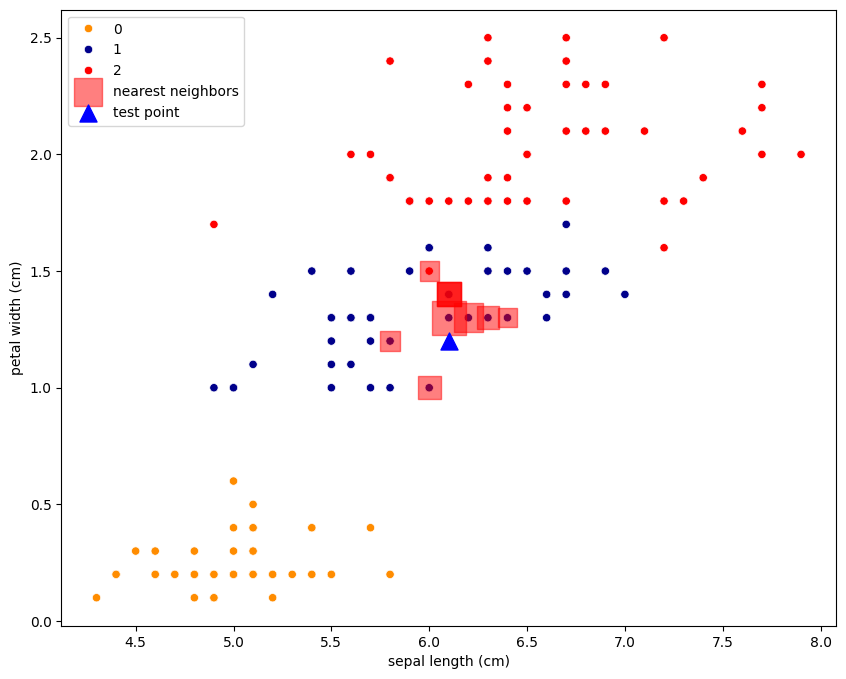

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_bold = ["darkorange", "darkblue", "red"]

nearest_neighbors_idxs = distances_df.sort_values('Distance from obj').head(k).index
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_train['sepal length (cm)'],
    y=X_train['petal width (cm)'],
    hue=y_train,
    palette=cmap_bold
)

plt.scatter(
    X_train.iloc[nearest_neighbors_idxs]['sepal length (cm)'],
    X_train.iloc[nearest_neighbors_idxs]['petal width (cm)'],
    c='red',
    alpha=0.5,
    marker='s',
    s=distances_df['weight'].iloc[nearest_neighbors_idxs]*60,
    label='nearest neighbors'
)

plt.scatter(
    X_test.iloc[obj_idx]['sepal length (cm)'],
    X_test.iloc[obj_idx]['petal width (cm)'],
    c='blue',
    marker='^',
    s=150,
    label='test point'
)

plt.legend()
plt.show()


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [79]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [80]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [81]:
Xset = pd.DataFrame(X['MedInc'][:1000])
yset = y[:1000]


### Отрисуйте данные на графике

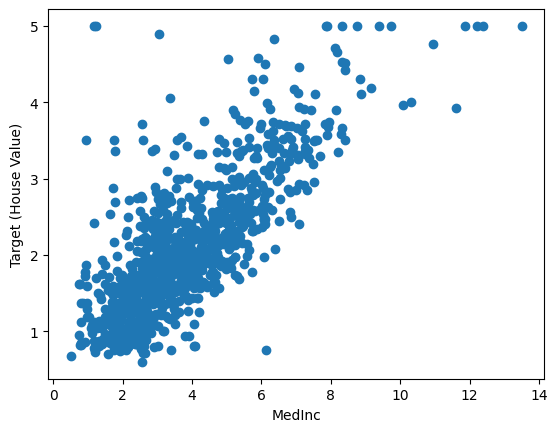

In [84]:
import matplotlib.pyplot as plt

plt.scatter(Xset, yset)
plt.xlabel('MedInc')
plt.ylabel('Target (House Value)')
plt.show()



### **4. KNN из sklearn**

#### 4.1. Разбейте данные на обучение и тест

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(Xset, yset, random_state=15, test_size=100)
X_train.shape, X_test.shape


((900, 1), (100, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [122]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=100)
model.fit(X_train, y_train)



KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели


In [123]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))


0.5318112013767231


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [129]:
import numpy as np

obj_idx = 1
x1 = X_test.iloc[obj_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df['Distance from obj'] = distance
distances_df


,Label,Distance from obj
0,2.952,3.9917
1,2.791,1.3221
2,3.004,3.0202
3,2.222,1.5340
4,1.063,1.2242
...,...,...
895,2.138,0.6009
896,3.673,4.4037
897,2.751,1.6533
898,1.612,0.8364


#### 4.5. Выберите топ  k  соседей


In [130]:
k=15
display(distances_df.sort_values('Distance from obj').head(k))

,Label,Distance from obj
40,1.512,0.0031
294,1.975,0.0031
123,1.095,0.0073
732,2.000,0.0073
181,2.189,0.0073
668,1.543,0.0083
622,2.094,0.0104
171,1.862,0.0157
287,2.422,0.0212
543,3.316,0.0222


#### 4.6. Выведите финальное предсказание для этого объекта

In [132]:
obj = distances_df.sort_values('Distance from obj').head(k)
print(f"Предсказание для первого объекта: {obj['Label'].median()}")

Предсказание для первого объекта: 1.871


#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [133]:
print(f"Настоящее целевое значение для объекта: {y_test[obj_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj_idx]}")


Настоящее целевое значение для объекта: 1.22
Предсказанное целевое значение для объекта: 1.9488100000000004


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

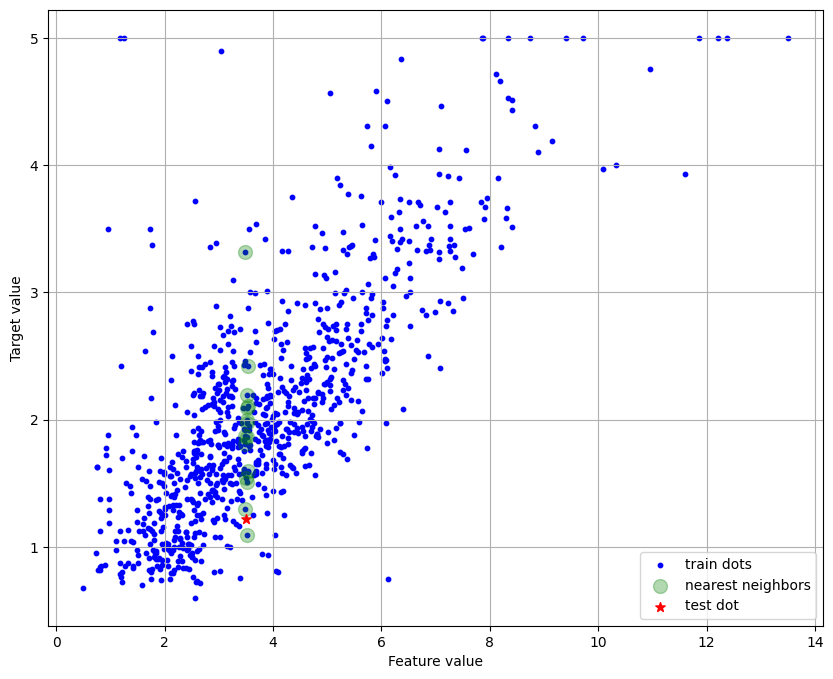

In [137]:
import matplotlib.pyplot as plt

nearest_neigbors_idxs = distances_df.sort_values('Distance from obj').head(k).index
plt.figure(figsize=(10, 8))

plt.scatter(X_train,
            y_train,
            c='b',
            marker='o',
            s=10,
            label='train dots')

plt.scatter(X_train.iloc[nearest_neigbors_idxs],
            y_train[nearest_neigbors_idxs],
            c='g',
            alpha=0.3,
            marker='o',
            s=100,
            label='nearest neighbors')

plt.scatter(X_test.iloc[obj_idx],
            y_test[obj_idx],
            c='r',
            marker='*',
            s=50,
            label='test dot')

plt.grid()
plt.ylabel('Target value')
plt.xlabel('Feature value')
plt.legend()

### **5. Weighted KNN**

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [138]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=50, weights='distance')
model.fit(X_train, y_train)


KNeighborsRegressor(n_neighbors=50, weights='distance')

#### 5.2. Проверьте качество работы модели


In [139]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
display(r2_score(y_test, y_pred))

0.45004144600382856

#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [142]:
import numpy as np

obj_idx = 2
x1 = X_test.iloc[obj_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df[f'Distance from obj'] = distance
distances_df

,Label,Distance from obj
0,2.952,4.1107
1,2.791,1.4411
2,3.004,3.1392
3,2.222,1.6530
4,1.063,1.1052
...,...,...
895,2.138,0.4819
896,3.673,4.5227
897,2.751,1.7723
898,1.612,0.7174


#### 5.4. Выберите топ  k  соседей


In [144]:
k=15
display(distances_df.sort_values('Distance from obj').head(k))


,Label,Distance from obj
600,1.793,0.0013
45,0.757,0.0036
812,2.713,0.0057
486,1.419,0.0065
59,1.969,0.0139
408,1.161,0.0143
119,1.983,0.0143
792,1.575,0.0143
758,1.439,0.0178
524,1.650,0.0183


#### 5.5. Рассчитайте вес для каждого соседа

In [146]:
distances_df['weight'] = 1 / distances_df['Distance from obj']
distances_df

,Label,Distance from obj,weight
0,2.952,4.1107,0.243268
1,2.791,1.4411,0.693914
2,3.004,3.1392,0.318552
3,2.222,1.6530,0.604961
4,1.063,1.1052,0.904814
...,...,...,...
895,2.138,0.4819,2.075119
896,3.673,4.5227,0.221107
897,2.751,1.7723,0.564239
898,1.612,0.7174,1.393922


#### 5.6. Выведите финальное предсказание для этого объекта

In [147]:
print((distances_df['Label'] * distances_df['weight']).sum() / distances_df['weight'].sum())


1.7869521502561838


#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [148]:
print(f"Настоящее целевое значение для объекта: {y_test[obj_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj_idx]}")


Настоящее целевое значение для объекта: 2.417
Предсказанное целевое значение для объекта: 1.7049888068969865


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

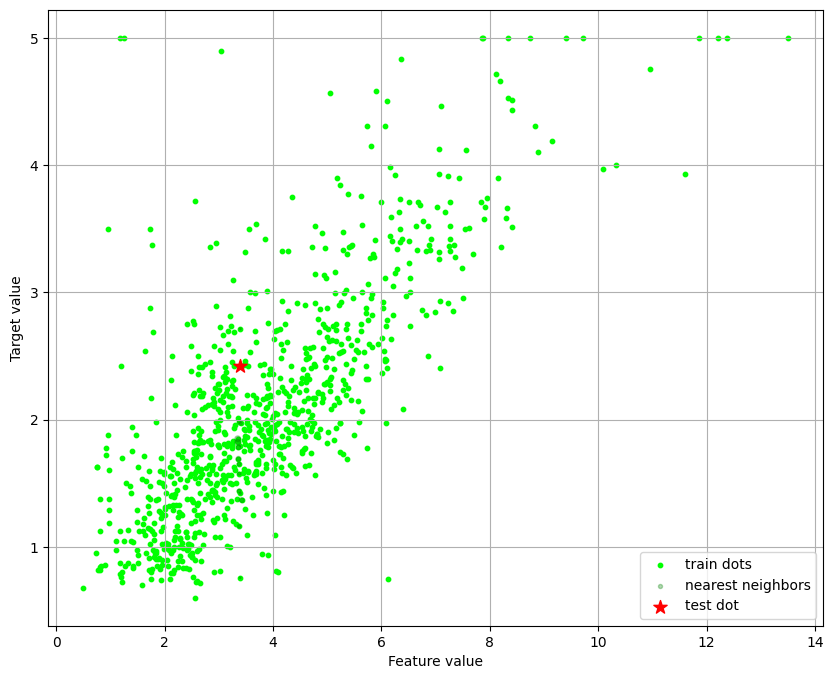

In [154]:
plt.figure(figsize=(10, 8))

nearest_neigbors_idxs = distances_df.sort_values('Distance from obj').head(k).index

plt.scatter(X_train,
            y_train,
            c='lime',
            marker='o',
            s=10,
            label='train dots')


plt.scatter(X_train.iloc[nearest_neigbors_idxs],
            y_train[nearest_neigbors_idxs],
            c='g',
            alpha=0.3,
            marker='o',
            s=distances_df['Distance from obj'].iloc[nearest_neigbors_idxs]*400,
            label='nearest neighbors')

plt.scatter(X_test['MedInc'].iloc[obj_idx],
            y_test[obj_idx],
            c='r',
            marker='*',
            s=100,
            label='test dot')

plt.grid()
plt.xlabel('Feature value')
plt.ylabel('Target value')

plt.legend()


## 6. Подберите лучшие гиперпараметры для последней модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [160]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

knn = KNeighborsRegressor()

k_range = list(range(1, 50))
param_grid = {'n_neighbors': k_range}

grid = GridSearchCV(knn, param_grid, cv=5)

grid_search = grid.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'n_neighbors': 32}
Best score: 0.5905120026700095
